## Deflections and timescales of cell reorientation

This code calculates the deflection angle and duration of a cell reorientattion (spontaneous transition from forward to backward motion)

**Input:**

*file_directory*: Path to folder containing the cell swimming timelapse

*file_name*: The name of the tif file of the timelapse to be analyzed

*pixel_size* : The pixel size of the timelapse 

*fps* : The framerate of the timelapse 

**Output:**

*[cell id]_mask.tif* : The mask of the detected cells

*centroid_tracking_points.csv*: A csv file with the positions of the centroid of teh cell in time

*results.csv* : A csv file with the timepoints and deflection of interest

In [ ]:
import os
import numpy as np
import tifffile
from tqdm import tqdm
from skimage import filters, measure
from skimage.morphology import label
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from scipy.signal import savgol_filter
import csv

from functions import show_frame_no_axes

### Input

In [2]:
### Path to swimming cell timelapse
file_directory =  "C:\\Users\\kourkoul\\SCRIPTS\\Paper_scripts\\example_data\\"
file_name      = "cell_01.tif"
file_path = file_directory + "\\" + file_name

fps = 1000
pixel_size = 0.46 # μm

### Loading the timelapse
imgs = tifffile.imread(file_path)
num_frames = imgs.shape[0]

### Creating output path

output_path = file_directory + "\\output_track\\"
if not os.path.exists(output_path):
    os.makedirs(output_path)

### Pre-processing

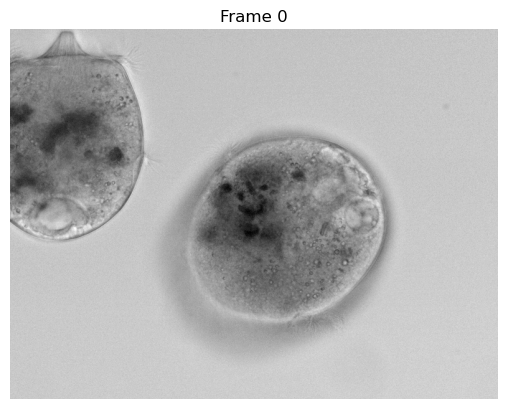

In [3]:
### Visualization of a given frame
frame_index = 0
show_frame_no_axes(imgs,frame_index)
plt.show()

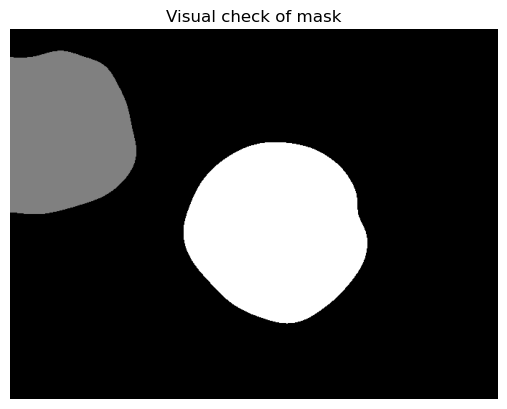

In [4]:
### Creating a mask
sigma = 20

masks = np.zeros_like(imgs)

# Blur
blurred = filters.gaussian(imgs[0],sigma=sigma) #, sigma=20
iso_threshold = filters.threshold_isodata(blurred)

# Binarize 
binary = blurred < iso_threshold
labeled = label(binary)

# Make mask for the first frame for visual inspection
mask = (labeled)
masks[0] = mask

plt.figure()
plt.title("Visual check of mask")
plt.imshow(mask, cmap='gray')     
plt.axis('off')
plt.show()

In [5]:
### Calculate the mask for the rest of the frames

for i in tqdm(range(1, imgs.shape[0])):
    blurred = filters.gaussian(imgs[i], sigma=sigma)
    
    try:
        iso_threshold = filters.threshold_isodata(blurred)
    except Exception as e:
        print(f"Blank page at frame {i} please delete this frame.")
        break
        
    binary = blurred < iso_threshold
    labeled = label(binary)
    regions = measure.regionprops(labeled)

    mask = (labeled)
    masks[i] = mask

100%|██████████| 363/363 [00:10<00:00, 35.50it/s]


In [6]:
### Saving the mask 

full_path = output_path + file_name[:-4] + "_mask.tif"

if len(full_path) > 260:
    # Construct the full file path
    full_path = os.path.join(output_path, file_name[:-4] + "_mask.tif")

    # Use the extended-length path prefix if needed
    if len(full_path) > 260:
       full_path = "\\\\?\\" + full_path
    tifffile.imwrite(full_path, (masks * 255).astype(np.uint8))
    
else:
    
    tifffile.imwrite(output_path + file_name[:-4] +"_mask.tif", (masks * 255).astype(np.uint8))

### Tracking centroid

In [7]:
### Defining usueful arrays
imgs_mask = masks
labeled_cells = label(imgs_mask)
unique_labels = np.unique(imgs_mask)

In [8]:
### Find centroids of detected objects for the whole timelapse

def find_centroids(frame):
    regions  =measure.regionprops(frame)
    
    centroids = []
    for region in regions:
        centroids.append(region.centroid)
    return centroids

centroids_array_frame_0 = np.array(find_centroids(imgs_mask[0]))
centroids_array_frame_0 = centroids_array_frame_0[np.newaxis, :, :]
if unique_labels[-1] > centroids_array_frame_0.shape[1]:
        rows_to_add = unique_labels[-1] - centroids_array_frame_0.shape[1]
        padding = np.zeros((1, rows_to_add, centroids_array_frame_0.shape[2]))
        centroid_tracking = np.append(centroids_array_frame_0, padding,axis=1)  
else:
    centroid_tracking =  np.empty((1,unique_labels[-1] ,2)) 

for i in range(1,num_frames):
    centroids_array = np.array(find_centroids(imgs_mask[i]))
    centroids_array = centroids_array[np.newaxis, :, :]
    if unique_labels[-1] > centroids_array.shape[1]:
        rows_to_add = unique_labels[-1] - centroids_array.shape[1]
        padding = np.zeros((1, rows_to_add, centroids_array.shape[2]))
        centroids_array = np.append(centroids_array, padding,axis=1)  

    centroid_tracking = np.append(centroid_tracking, centroids_array, axis=0)

print(centroid_tracking.shape)

(364, 2, 2)


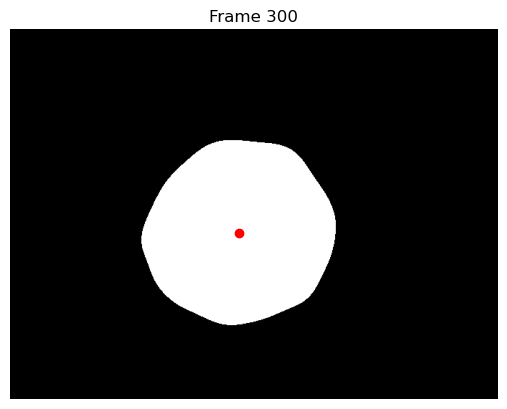

In [9]:
### Plotting centroid for visual inspection
frame_index = 300
show_frame_no_axes(imgs_mask,frame_index)
plt.scatter(centroid_tracking[frame_index][0][1],centroid_tracking[frame_index][0][0], c ="r")
plt.show()

In [12]:
### Sorting centroids based on frame-to-frame distance in case of multiple objects
def sort_centroids(centroid_tracking):
    num_frames, num_centroids, _ = centroid_tracking.shape
    sorted_tracking = np.zeros_like(centroid_tracking)
    sorted_masks = np.zeros_like(imgs_mask)
    
    sorted_tracking[0] = centroid_tracking[0]
    sorted_masks[0] = imgs_mask[0]

    for t in range(1, num_frames):
        prev_frame = sorted_tracking[t - 1]  
        curr_frame = centroid_tracking[t]    
        curr_mask = imgs_mask[t]            
            
        # Compute pairwise distances between previous and current centroids
        distances = cdist(prev_frame, curr_frame)
        
        # Minimize distances to match objects in time
        assigned_indices = []
        for _ in range(num_centroids):
            i, j = divmod(np.argmin(distances), distances.shape[1])
            assigned_indices.append((i, j))
            distances[i, :] = np.inf 
            distances[:, j] = np.inf  

        # Reordering current frame centroids to match the previous frame
        sorted_tracking[t] = curr_frame[[j for _, j in sorted(assigned_indices)]]

        # Correcting the mask labels
        new_mask = np.zeros_like(curr_mask)
        for i, j in sorted(assigned_indices):
            new_mask[curr_mask == j + 1] = i + 1
        sorted_masks[t] = new_mask
        
    return sorted_tracking, sorted_masks

sorted_tracking, sorted_masks = sort_centroids(centroid_tracking)
sorted_tracking = sorted_tracking[1:]

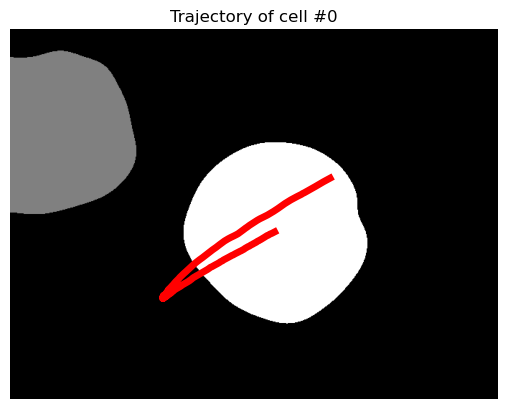

In [15]:
frame_array = np.arange(sorted_tracking.shape[0]) / fps

### Select object for the analysis
cell_id = 0
num_frames, height, width = sorted_masks.shape

# Optional cropping in case of cell going out of frame
until = -1 
plt.figure()
plt.imshow(sorted_masks[0], cmap="gray")
plt.plot(sorted_tracking[1:,cell_id,1][:until], sorted_tracking[1:,cell_id,0][:until],linewidth=5, color = 'red')
plt.ylabel('Y')
plt.title('Trajectory of cell #' + str(0))
plt.grid(False)
plt.axis("off")
plt.show()

### Saving the centorid positions
df = pd.DataFrame({'X': sorted_tracking[1:,cell_id,0], 'Y': sorted_tracking[1:,cell_id,1]})
df.to_csv(output_path + "centroid_track_points.csv")

### Time evolution of speed an orientation

In [16]:
### Conversion to real units
translations_to_analyze = sorted_tracking[:,cell_id,:]
translations_to_analyze = translations_to_analyze * pixel_size /1000
time = np.arange(0, translations_to_analyze.shape[0])
time_steps = np.diff(time)
time_axis_sec = time[:-1] / fps

In [17]:
### Calculation of linear velocity
velocities = []
velocities = np.diff(translations_to_analyze, axis = 0) * fps
speed_cell = np.linalg.norm(velocities, ord=2,  axis=1) 

### To smooth for noise/abrupt peaks:
window_size_mov_av = 100  
speed_series = pd.Series(speed_cell)
speed_cell_smooth = speed_series.rolling(window=window_size_mov_av, center=True, min_periods=1).mean()
velocity_series_x = pd.Series(velocities[:,0])
velocity_series_x = velocity_series_x.rolling(window=10, center=True, min_periods=1).mean()
velocity_series_y = pd.Series(velocities[:,1])
velocity_series_y = velocity_series_y.rolling(window=10, center=True, min_periods=1).mean()
velocities_smooth =  np.column_stack((velocity_series_y, velocity_series_y))


In [18]:
### Calculation of instantaneous angle and orientation
dot_product = np.sum(velocities[:-1, :] * velocities[1:, :], axis=1)
norms_prev = np.linalg.norm(velocities[:-1, :], axis=1)
norms_next = np.linalg.norm(velocities[1:, :], axis=1)
denominator = np.clip(norms_prev * norms_next, a_min=1e-18, a_max=None)

cosine_of_consequetive_angle = dot_product / denominator

### Angle from 0 to π
angles = np.arccos(np.clip(cosine_of_consequetive_angle, -1.0, 1.0))

# Correction to have it from -π to +π:
cross_product_z = (velocities[:-1, 0] * velocities[1:, 1] - 
                   velocities[:-1, 1] * velocities[1:, 0])

### Adjusting angle based on cross product sign
signed_angles_in_rad = np.where(cross_product_z >= 0, angles, -angles)
signed_angles_in_deg = np.degrees(signed_angles_in_rad)

absolute_signed_angles_in_rad = np.abs(signed_angles_in_rad)
absolute_signed_angles_in_deg = np.abs(signed_angles_in_deg)

### Calculation of cumulative reorientation
cumulative_angles_in_rad = np.cumsum(signed_angles_in_rad)
cumulative_angles_in_deg = np.cumsum(signed_angles_in_deg)

window_size_mov_av = 50  # keep it very small
cumul_angles_series = pd.Series(cumulative_angles_in_deg)
cumul_angles_smooth = cumul_angles_series.rolling(window=window_size_mov_av, center=True, min_periods=1).mean()




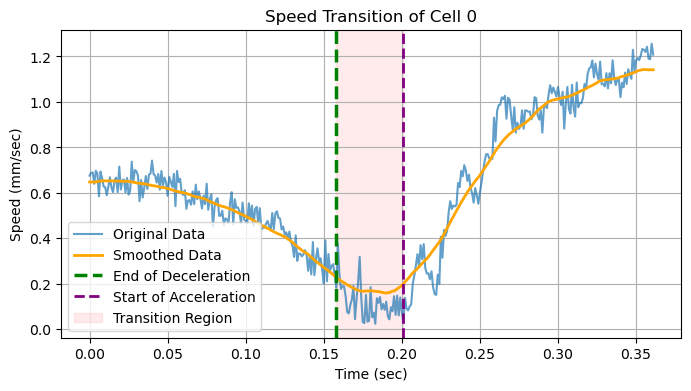

End of deceleration at time: 0.158 sec
Start of acceleration at time: 0.201 sec


In [22]:
### Identifying the timepoints of interest

# Define parameters
window_size_mov_av = 70  
frame_array = time_axis_sec
# Smoothing the speed data
speed_series = pd.Series(speed_cell)
speed_cell_smooth = speed_series.rolling(window=window_size_mov_av, center=True, min_periods=1).mean()

# Computing the derivative (dv/dt)
time_intervals = np.diff(frame_array)  # Time intervals
dv_dt = np.gradient(speed_cell_smooth, time_intervals.mean())  

# Applying Savitzky-Golay filter for smoothing
dv_dt = savgol_filter(dv_dt, window_length=50, polyorder=3)
std_dv_dt = np.std(dv_dt)

diffs = np.diff(np.where(dv_dt > -std_dv_dt)[0])
# Find indices where the difference is greater than 1
jump_indices = np.where(diffs > 1)[0] + 1  # +1 to get the actual split positions

# Split the array at these indices
subarrays = np.split(np.where(dv_dt > -std_dv_dt)[0], jump_indices)

end_decel_idx = subarrays[1][0]  
start_accel_idx = np.where(dv_dt > std_dv_dt)[0][0] 

# Get corresponding times
end_decel_time = frame_array[end_decel_idx]
start_accel_time = frame_array[start_accel_idx]

fig, ax = plt.subplots(figsize=(8, 4))

# Plot only speed
ax.plot(frame_array, speed_cell, label='Original Data', alpha=0.7)
ax.plot(frame_array, speed_cell_smooth, label='Smoothed Data', color='orange', linewidth=2)
ax.set_xlabel('Time (sec)')
ax.set_ylabel('Speed (mm/sec)')
ax.tick_params(axis='y')
ax.grid(True)

# Mark transition points
ax.axvline(end_decel_time, color='green', linestyle="--", linewidth=2.5, label="End of Deceleration")
ax.axvline(start_accel_time, color='purple', linestyle="--", linewidth=2,  label="Start of Acceleration")
ax.axvspan(end_decel_time, start_accel_time, color='red', alpha=0.08, label='Transition Region')

# Legend and title
ax.legend(loc='lower left')
plt.title(f'Speed Transition of Cell {cell_id}')
plt.show()

# Print results
print(f"End of deceleration at time: {end_decel_time:.3f} sec")
print(f"Start of acceleration at time: {start_accel_time:.3f} sec")


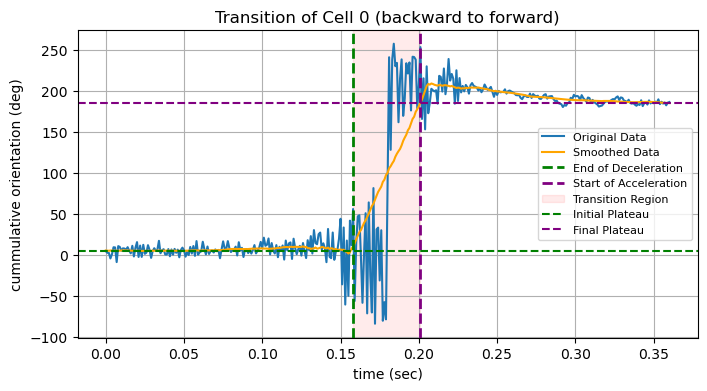

In [ ]:
### Identifying the original and final direction
transition_duration = []
end_time_all = []

frame_Array = time_axis_sec[:-1]
### Calculate a running mean
window_size = 50 
running_mean = cumul_angles_smooth
running_frame_array = frame_array[window_size-1:]  

### Define thresholds based on the initial and final plateaus
initial_plateau = np.mean(running_mean[:window_size]) 
final_plateau = np.mean(running_mean[-window_size:])  

num_plateaus = 0.1  # Use first 3 windows and last 3 windows

### Calculate Initial Plateau (mean of first x windows)**
initial_plateau = np.mean(running_mean[:int(num_plateaus * window_size)])  
### Calculate Final Plateau (mean of last x windows)**
final_plateau = np.mean(running_mean[-int(num_plateaus * window_size):]) 

transition_start_idx = np.where(np.abs(running_mean - initial_plateau) > 0.05*np.std(running_mean))[0][0]
transition_end_idx = np.where(np.abs(running_mean - final_plateau)  <  0.05*np.std(running_mean) )[0][1]

start_time = frame_array[transition_start_idx]
end_time = frame_array[transition_end_idx]

### Plotting results
plt.figure(figsize=(8, 4))
plt.plot(time_axis_sec[:-1], cumulative_angles_in_deg, label='Original Data', alpha=1)
plt.plot(time_axis_sec[:-1], cumul_angles_smooth, label='Smoothed Data', color='orange', alpha=1)
plt.axvline(end_decel_time, color='green', linestyle="--", linewidth=2, label="End of Deceleration")
plt.axvline(start_accel_time, color='purple', linestyle="--", linewidth=2,  label="Start of Acceleration")
plt.axvspan(end_decel_time, start_accel_time, color='red', alpha=0.08, label='Transition Region')
plt.axhline(initial_plateau, color='green', linestyle='--', label='Initial Plateau')
plt.axhline(final_plateau, color='purple', linestyle='--', label='Final Plateau')
plt.xlabel('time (sec)')
plt.ylabel('cummulative orientation (deg)')
plt.title('Transition of Cell ' + str(0) +' (backward to forward)')
plt.legend(fontsize=8)
plt.grid(True)
plt.show()

In [24]:
plateau_difference = (final_plateau-initial_plateau)
print(plateau_difference)


179.77567523805368


17.84311591671297


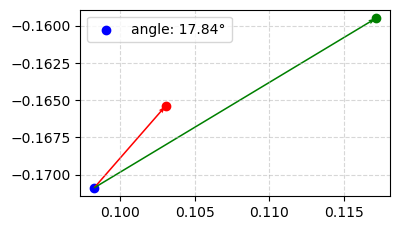

In [29]:
### Deflection angle 

def find_and_plot_angle(A, B, C):
    A, B, C = np.array(A), np.array(B), np.array(C)
    
    # Compute vectors
    AB, BC = A - B, C - B

    # Compute angle and plot an arc
    angle = np.degrees(np.arccos(np.clip(np.dot(AB, BC) / (np.linalg.norm(AB) * np.linalg.norm(BC)), -1.0, 1.0)))
    theta = np.linspace(0, np.radians(angle), 100)
   
    # Plot points
    plt.figure(figsize=(4,4))
    plt.scatter(*A, color="red")
    plt.scatter(*B, color="blue", label="angle: " + str(round(angle,2)) + "°")
    plt.scatter(*C, color="green")

    # Plot vectors
    plt.quiver(*B, *AB, angles='xy', scale_units='xy', scale=1, color="red", width=0.005)
    plt.quiver(*B, *BC, angles='xy', scale_units='xy', scale=1, color="green", width=0.005)

    print(angle)
    
#     plt.text(B[0] - 0.001, B[1] - 0.001, f"{angle:.1f}°", fontsize=12, color="blue")
    
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.gca().set_aspect('equal', adjustable='box')
    plt.show()
    
    return angle

check_points_angles = np.array([start_time, end_decel_time, start_accel_time, end_time]) * fps
check_points_angles = check_points_angles.astype(int)


A_1 = [translations_to_analyze[check_points_angles[3]+30,1], -translations_to_analyze[check_points_angles[3]+30,0]]
B_1 = [translations_to_analyze[check_points_angles[3],1], -translations_to_analyze[check_points_angles[3],0]]
C_1 = [translations_to_analyze[check_points_angles[2]-100,1], -translations_to_analyze[check_points_angles[2]-100,0]]

instant_angle = find_and_plot_angle(A_1, B_1, C_1)


### Saving the output 

In [28]:
headers = ["start_time", "end_decel_time", "start_accel_time", "end_time", "plateau_difference", "instant_angle"]

# Write to CSV
with open(output_path+"results.csv", mode="w", newline="") as file:
    writer = csv.writer(file)
    writer.writerow(headers)  # Write the header
    writer.writerow([start_time, end_decel_time, start_accel_time, end_time, plateau_difference, instant_angle])